# Major Project: Seasonal Agriculture Performance Analysis

# Name: ANIRBAN BISHNU
# College: University Institute of Technology
# VOIS AICTE Batch 1 (2026–2027)
# AICTE STU ID :  STU6a6788dc7129f1785170140
### Objective
To analyze agricultural performance across different seasons and identify
meaningful patterns, trends, relationships, and variations in agricultural
production, yield, resource usage, environmental conditions, and economic
performance.

# Import Libraries

In [ ]:
from ast import increment_lineno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import  stats

import warnings
warnings.filterwarnings("ignore")



# Load the Dataset

In [ ]:
from google.colab import files

uploaded=files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [ ]:
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


# Understand the Dataset

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


### Dataset Dimensions

In [ ]:
print("Rows : ",df.shape[0])

Rows :  4000


In [ ]:
print("Columns : ",df.shape[1])

Columns :  28


# Check Column Names

In [ ]:
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

# Understand Data Types

In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


# Statistical Summary

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


# Check Missing Values

In [ ]:
missing=df.isnull().sum()

In [ ]:
missing

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
missing[missing>0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


# Check Missing Percentage

In [ ]:
missing_percentage=((missing/len(df))*100)


In [ ]:
missing_percentage

,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,1.2
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


In [ ]:
missing_table=pd.DataFrame({
    "Missing Values":missing,
    "Missing Percentage":missing_percentage
})

In [ ]:
missing_table

,Missing Values,Missing Percentage
Farm_ID,0,0.0
State,0,0.0
District,0,0.0
Crop,0,0.0
Season,0,0.0
Farm_Area_Hectares,0,0.0
Rainfall_mm,48,1.2
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0
Sunlight_Hours_Day,0,0.0


# Handle Missing Values

In [ ]:
missing_table[missing>0]

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [ ]:
df["Rainfall_mm"]=df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

In [ ]:
df["Soil_Moisture_pct"]=df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())

In [ ]:
df["Yield_Tonnes_Ha"]=df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


# Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (4000, 28)


# Check Unique Values

In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
categorical_columns=[
        'State',
    'District',
    'Crop',
    'Season',
    'Irrigation_Method'
]

In [ ]:
for col in categorical_columns:
  print("\n",col)
  print(df[col].value_counts())


 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


# Basic Dataset Information

In [ ]:
print("Number of farms:", df['Farm_ID'].nunique())
print("Number of states:", df['State'].nunique())
print("Number of districts:", df['District'].nunique())
print("Number of crops:", df['Crop'].nunique())
print("Number of seasons:", df['Season'].nunique())
print("Number of irrigation methods:", df['Irrigation_Method'].nunique())

Number of farms: 4000
Number of states: 8
Number of districts: 10
Number of crops: 8
Number of seasons: 3
Number of irrigation methods: 4


# Season Distribution

In [ ]:
df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


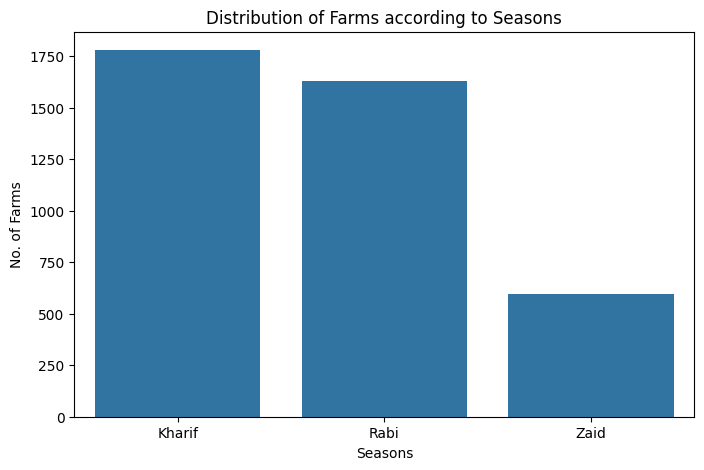

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Season")

plt.xlabel("Seasons")
plt.ylabel("No. of Farms")

plt.title("Distribution of Farms according to Seasons")

plt.show()

# Question 1 - How does agricultural performance vary across seasons?

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
season_summary=df.groupby("Season").agg({
        'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Total_Cost_INR': 'mean'
}).round(2)

In [ ]:
season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Total_Cost_INR
Season,,,,,
Kharif,5.63,46.31,710719.06,178914.65,531804.41
Rabi,5.04,41.49,601526.05,87689.47,513836.58
Zaid,4.64,38.89,519171.90,-24804.82,543976.73


# Average Yield by Season

In [ ]:
yeild_season=df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

In [ ]:
yeild_season

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


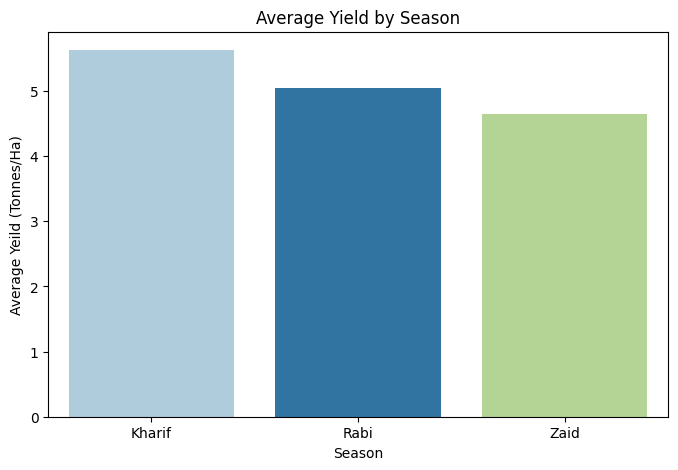

In [ ]:
#Graph

plt.figure(figsize=(8,5))

sns.barplot(x=yeild_season.index,
            y=yeild_season.values,
            palette="Paired")

plt.xlabel("Season")
plt.ylabel("Average Yeild (Tonnes/Ha)")
plt.title("Average Yield by Season")
plt.show()


# Production by Season

In [ ]:
production_season=df.groupby('Season')['Production_Tonnes'].sum()

In [ ]:
production_season

,Production_Tonnes
Season,
Kharif,82387.61
Rabi,67498.88
Zaid,23098.35


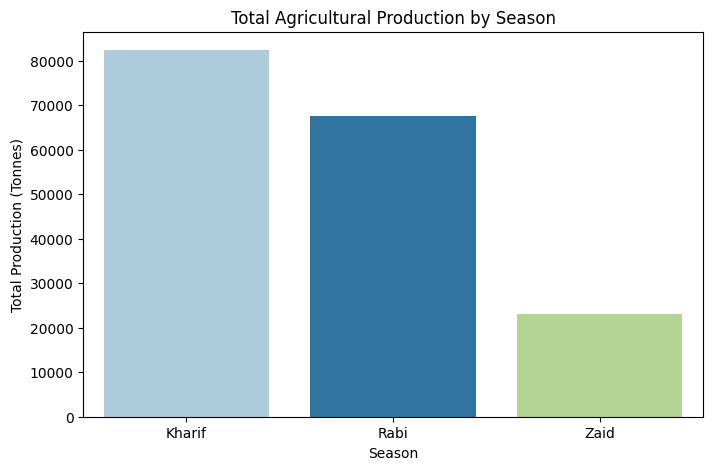

In [ ]:
#Graph


plt.figure(figsize=(8,5))

sns.barplot(x=production_season.index,
            y=production_season.values,
            palette="Paired")

plt.title('Total Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Total Production (Tonnes)')
plt.show()


# Revenue by Season

In [ ]:
revenue_season = df.groupby("Season")["Revenue_INR"].mean().sort_values(ascending=False)

In [ ]:
revenue_season

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


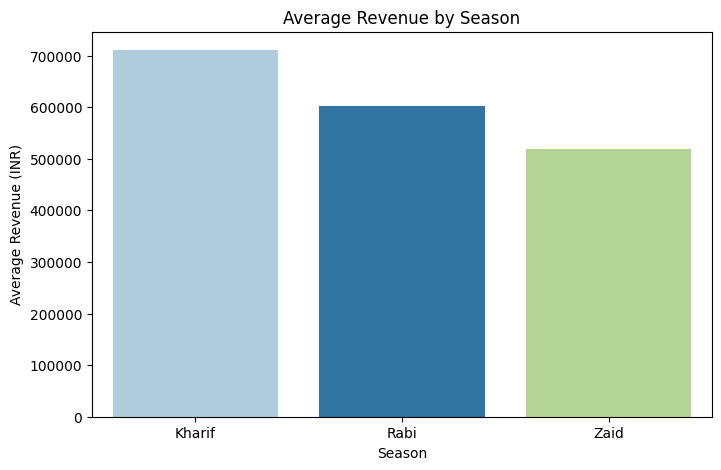

In [ ]:
#Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_season.index,
    y=revenue_season.values,
     palette="Paired"
)

plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.show()

# Profit by Season

In [ ]:
profit_season=df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)



In [ ]:
profit_season

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


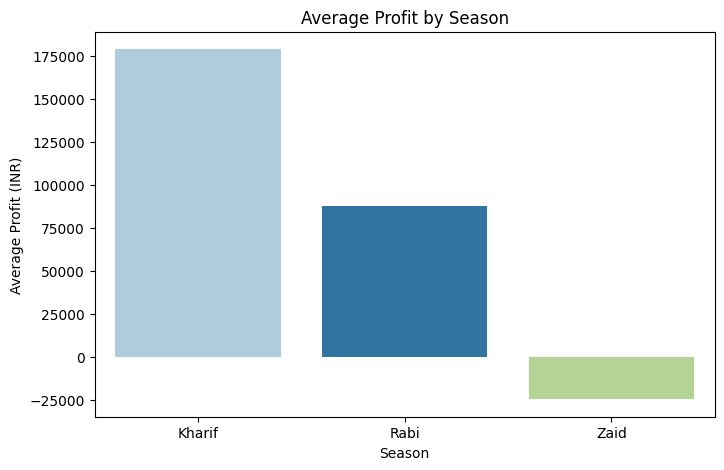

In [ ]:
# Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_season.index,
    y=profit_season.values,
    palette="Paired"
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

# Cost vs Revenue vs Profit

In [ ]:
economic_summary = df.groupby("Season").agg({
        'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

In [ ]:
economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


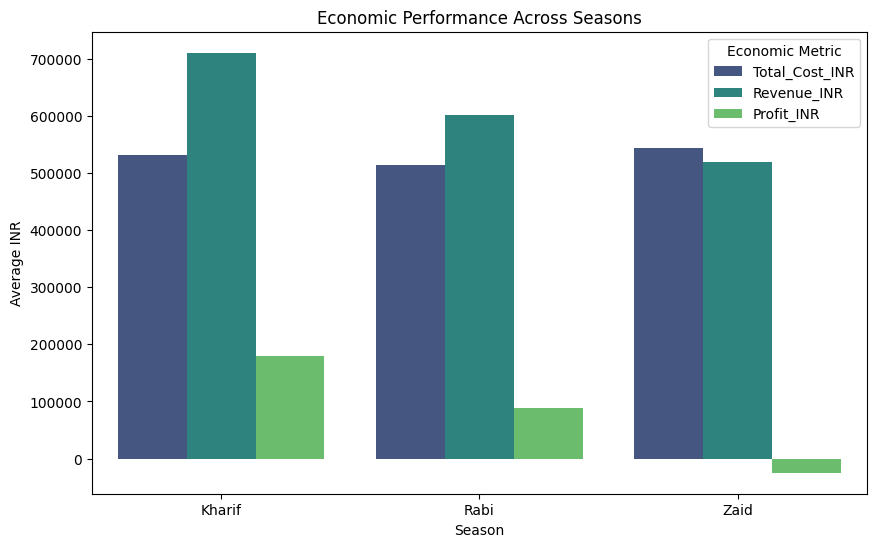

In [ ]:
# Graph
economic_summary_melted = economic_summary.reset_index().melt(id_vars='Season', var_name='Metric', value_name='Amount')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=economic_summary_melted,
    x='Season',
    y='Amount',
    hue='Metric',
    palette='viridis' # Choose a suitable palette
)

plt.title('Economic Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average INR')
plt.xticks(rotation=0)
plt.legend(title='Economic Metric')
plt.show()

# Question 2
What environmental conditions change between seasons?

In [ ]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [ ]:
environmental_summary=df.groupby("Season").agg({
    'Rainfall_mm':"mean",
 'Avg_Temperature_C':"mean",
 'Humidity_pct':"mean",
 'Sunlight_Hours_Day':"mean",
 'Soil_pH':"mean",
})

In [ ]:
environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,6.727993
Rabi,437.615366,23.489183,57.893178,7.589797,6.673749
Zaid,304.654714,31.042088,52.012121,8.178788,6.694865


#Environmental Visualization

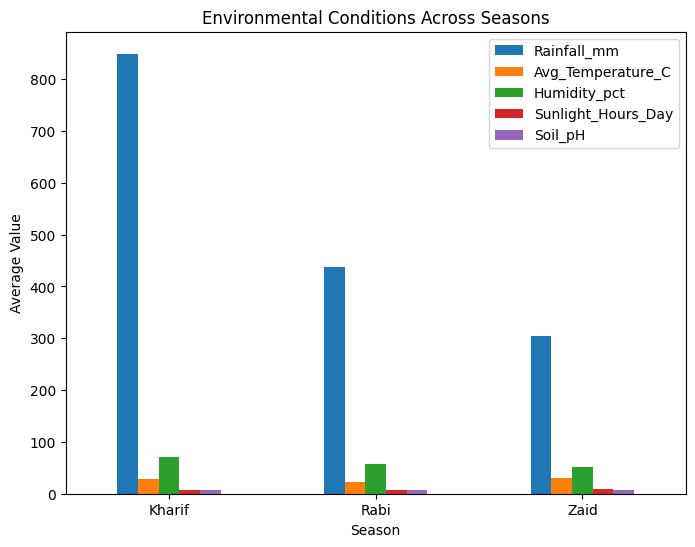

In [ ]:
environmental_summary.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title('Environmental Conditions Across Seasons')
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

## Rainfall

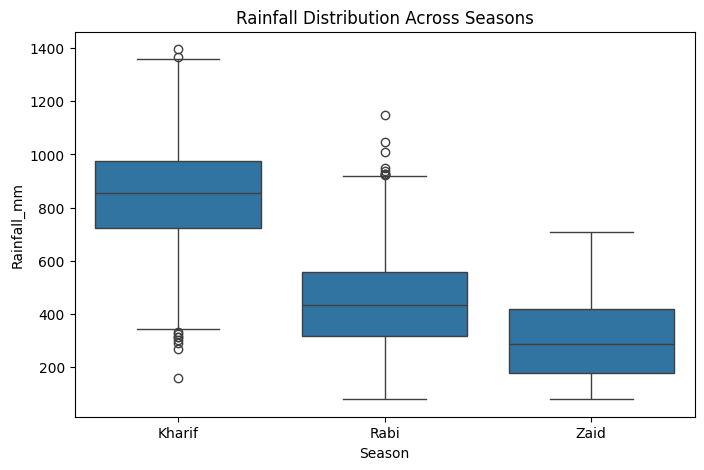

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title('Rainfall Distribution Across Seasons')
plt.show()

## Temperature

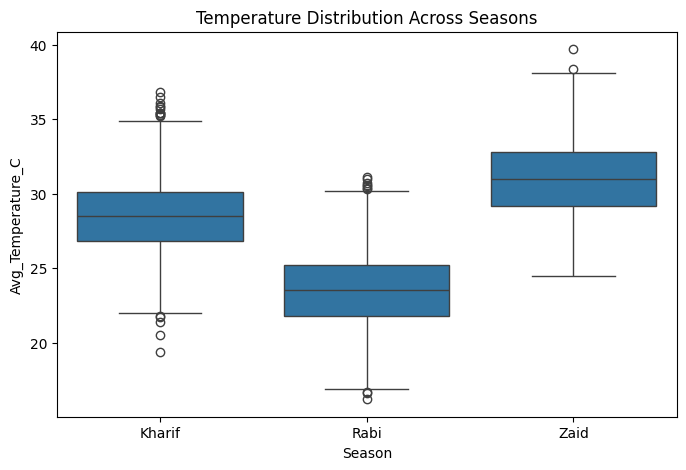

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title('Temperature Distribution Across Seasons')
plt.show()

## Humidity

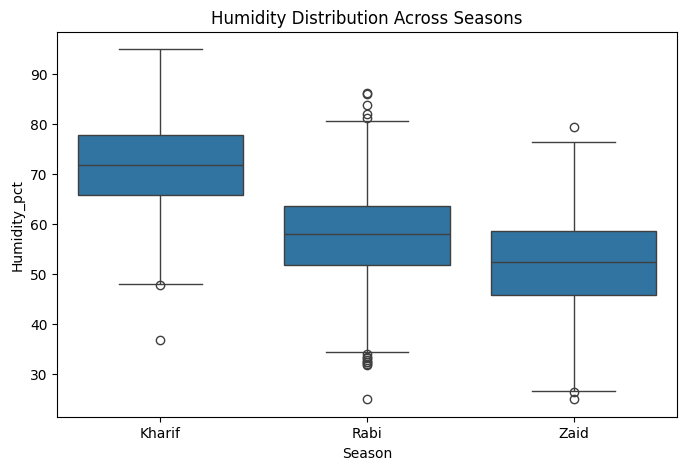

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Humidity_pct'
)

plt.title('Humidity Distribution Across Seasons')
plt.show()

# Question 3
How does resource usage vary across seasons?

In [ ]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [ ]:
resource_summary=df.groupby("Season").agg({
     'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean'
}).round(2)

In [ ]:
resource_summary

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


# Resource Usage Visualization

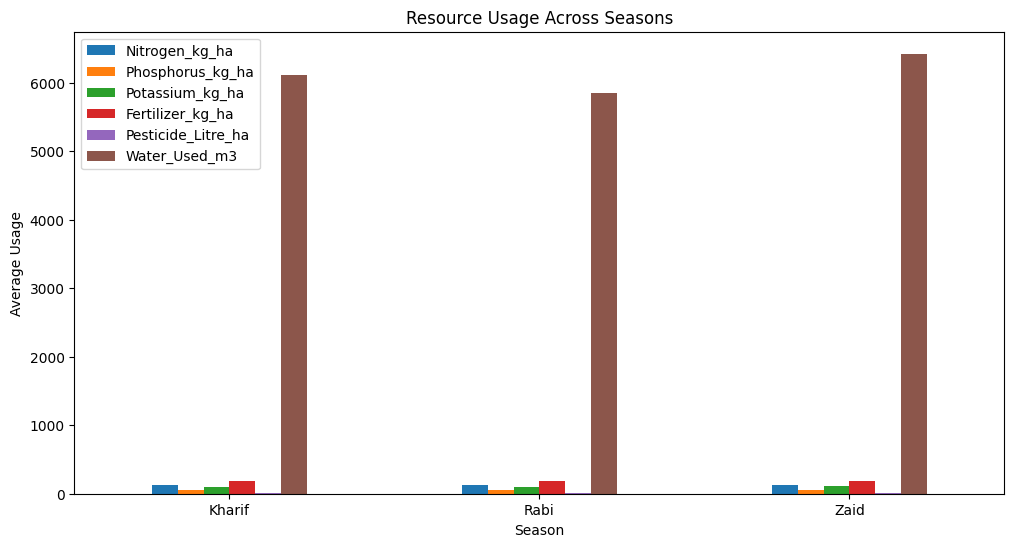

In [ ]:
resource_summary.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Resource Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Usage')
plt.xticks(rotation=0)
plt.legend()
plt.show()

# Irrigation Method Analysis

In [ ]:
pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [ ]:
Irrigation_percentage=pd.crosstab(
    df['Season'],
    df['Irrigation_Method'],
    normalize='index'
)*100

Irrigation_percentage.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


## Visualization:

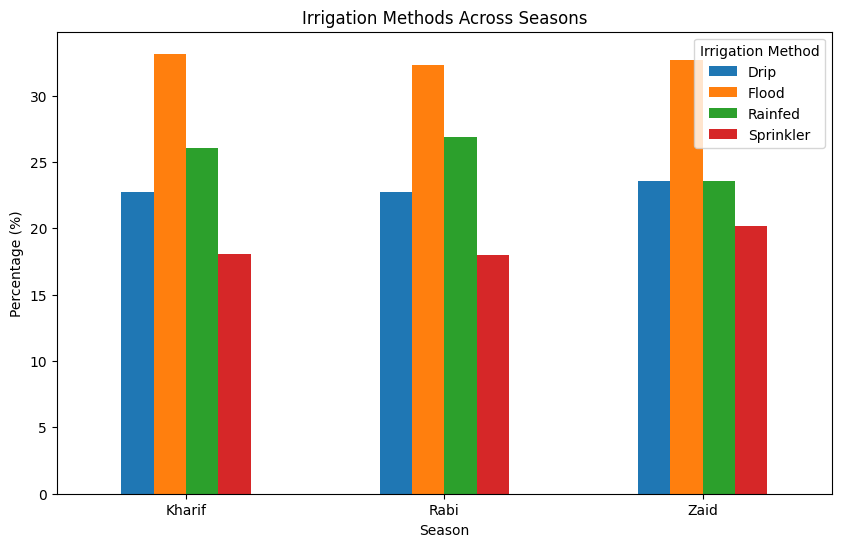

In [ ]:
Irrigation_percentage.plot(
    kind='bar',
    stacked=False,
    figsize=(10,6)
)

plt.title('Irrigation Methods Across Seasons')
plt.xlabel('Season')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.show()

# Water Efficiency

In [ ]:
water_efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().sort_values(ascending=False)


In [ ]:
water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


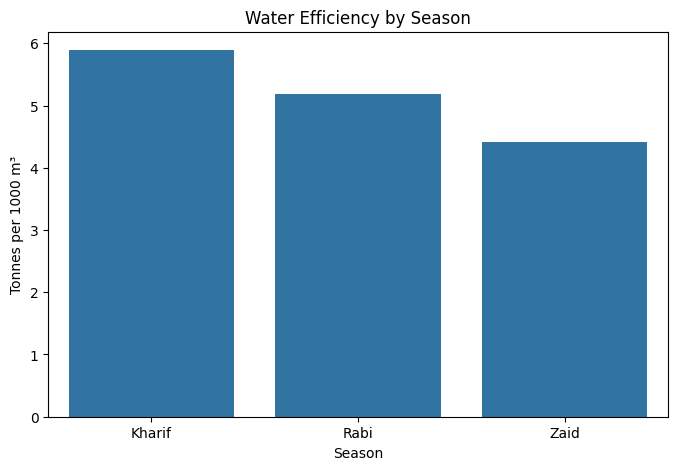

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')
plt.show()

# Question 4
How do crops perform across different seasons?

In [ ]:
crop_season = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


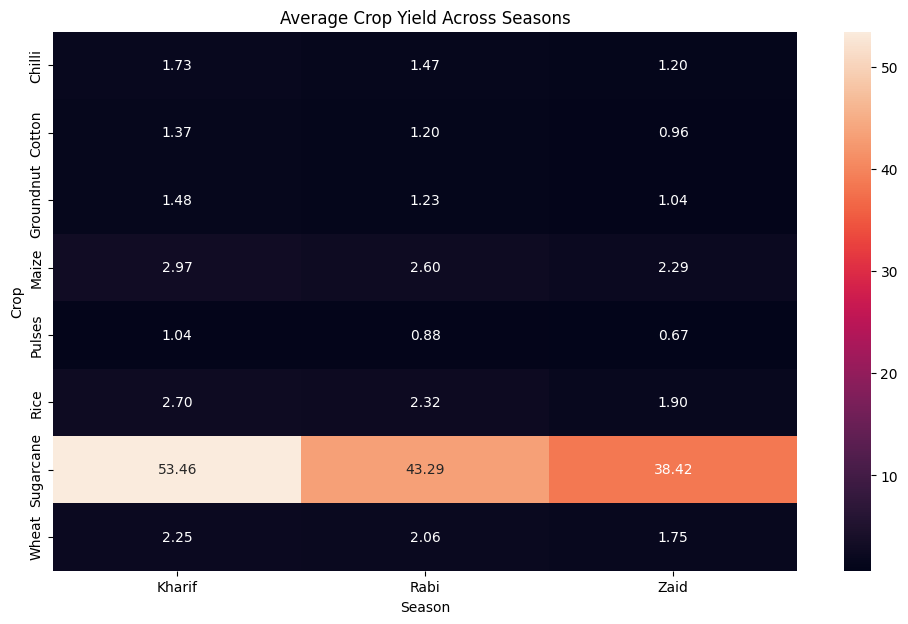

In [ ]:
plt.figure(figsize=(12,7))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

# Best Crop in Each Season

In [ ]:
best_crop = df.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].mean().reset_index()

best_crop.loc[
    best_crop.groupby('Season')['Yield_Tonnes_Ha'].idxmax()
]

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.286124
22,Zaid,Sugarcane,38.423922


# Question 5
How does agricultural performance vary by state?

In [ ]:
state_summary = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)



In [ ]:
state_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
State,,,,
Andhra Pradesh,4.63,36.91,606663.66,73453.53
Gujarat,5.66,48.33,654692.86,117568.24
Karnataka,5.69,47.73,653426.18,119422.34
Madhya Pradesh,4.99,37.56,597558.36,86840.76
Maharashtra,5.02,43.98,650032.67,135428.86
Punjab,6.12,52.23,686225.70,136025.64
Tamil Nadu,4.88,40.84,629093.42,117744.75
Telangana,5.04,39.25,628784.53,108829.62


# State-wise Profit

In [ ]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(
    ascending=False
)

state_profit

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


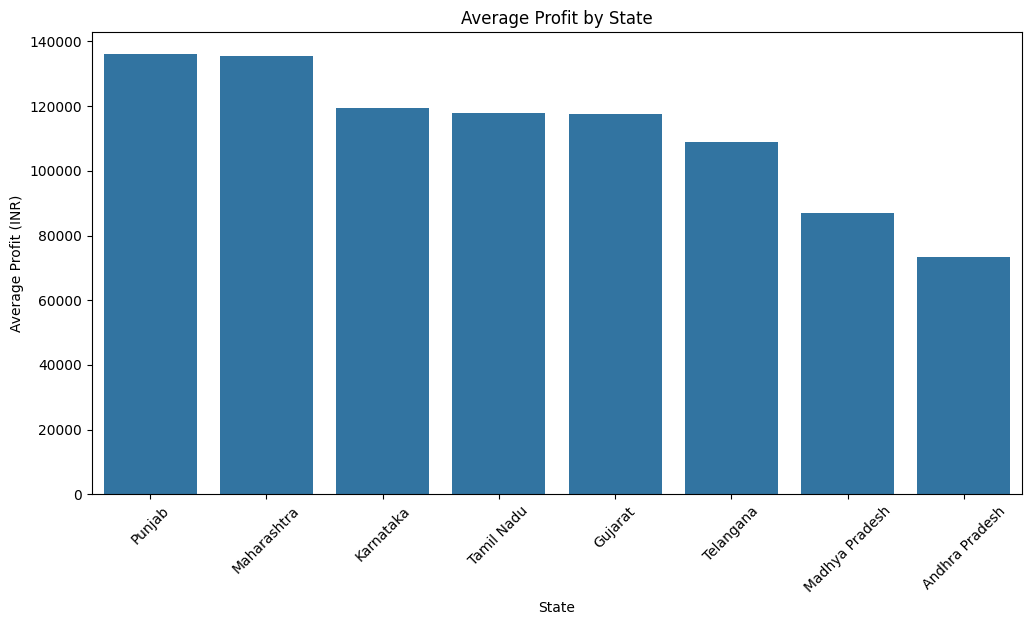

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_profit.index,
    y=state_profit.values
)

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

# Season + State Analysis

In [ ]:
state_season_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season_profit.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


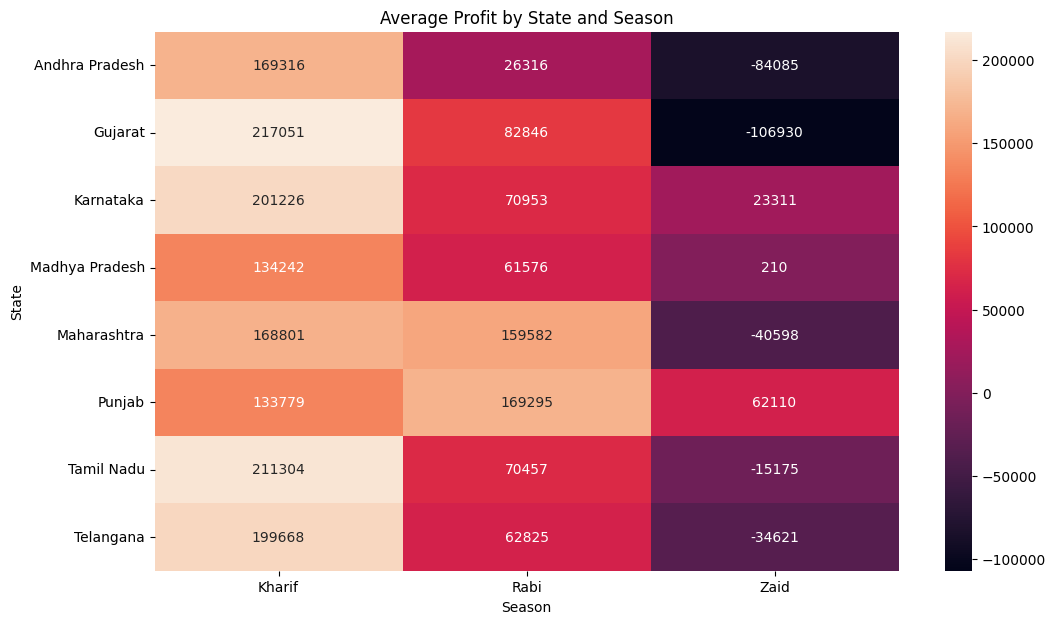

In [ ]:
plt.figure(figsize=(12,7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt='.0f'
)

plt.title('Average Profit by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.show()

# Question 6
Is there a relationship between environmental factors and yield?


In [ ]:
environment_yield = df[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_pH',
        'Soil_Moisture_pct',
        'Yield_Tonnes_Ha'
    ]
]

environment_yield.corr()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.030951
Avg_Temperature_C,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.009996
Humidity_pct,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.012297
Sunlight_Hours_Day,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,-0.015341
Soil_pH,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,-0.020672
Soil_Moisture_pct,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.010999
Yield_Tonnes_Ha,0.030951,0.009996,0.012297,-0.015341,-0.020672,0.010999,1.000000


# Correlation Heatmap

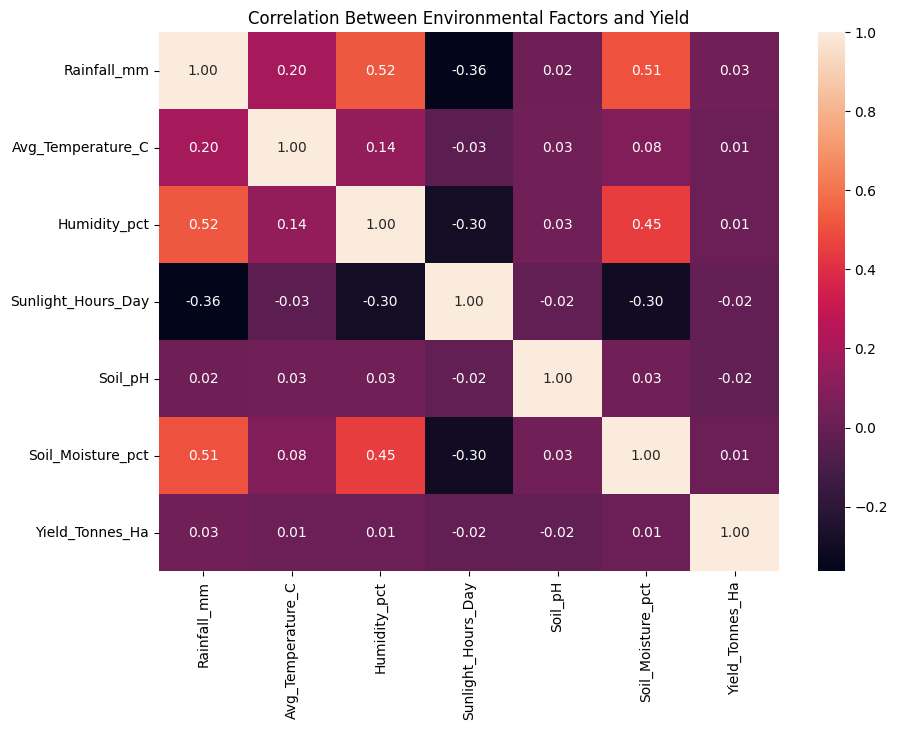

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    environment_yield.corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Environmental Factors and Yield')
plt.show()

# Resource vs Yield Correlation

In [ ]:
resource_yield = df[
    [
        'Nitrogen_kg_ha',
        'Phosphorus_kg_ha',
        'Potassium_kg_ha',
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3',
        'Yield_Tonnes_Ha'
    ]
]

resource_yield.corr()

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
Nitrogen_kg_ha,1.000000,0.010199,0.010490,-0.032440,0.014280,0.022127,0.054896,0.053149
Phosphorus_kg_ha,0.010199,1.000000,0.002847,0.012905,-0.029942,-0.000752,0.057129,0.047941
Potassium_kg_ha,0.010490,0.002847,1.000000,0.017254,-0.004675,0.001667,0.006575,0.003382
Fertilizer_kg_ha,-0.032440,0.012905,0.017254,1.000000,-0.001178,0.000895,0.005077,0.000018
Pesticide_Litre_ha,0.014280,-0.029942,-0.004675,-0.001178,1.000000,0.002177,-0.006330,-0.007779
Water_Used_m3,0.022127,-0.000752,0.001667,0.000895,0.002177,1.000000,0.217081,0.386294
Water_Efficiency_t_per_1000m3,0.054896,0.057129,0.006575,0.005077,-0.006330,0.217081,1.000000,0.912568
Yield_Tonnes_Ha,0.053149,0.047941,0.003382,0.000018,-0.007779,0.386294,0.912568,1.000000


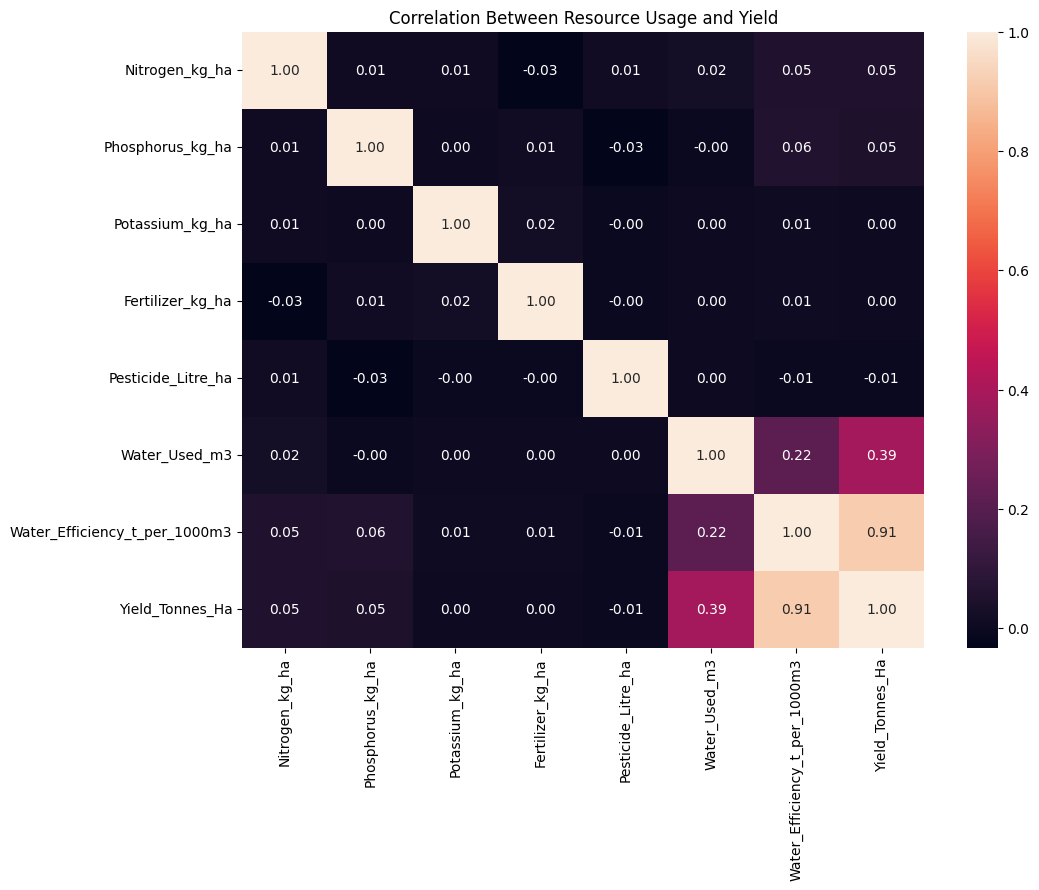

In [ ]:
plt.figure(figsize=(11,8))

sns.heatmap(
    resource_yield.corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Resource Usage and Yield')
plt.show()

# Economic Correlation

In [ ]:
economic = df[
    [
        'Farm_Area_Hectares',
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Market_Price_INR_Tonne',
        'Total_Cost_INR',
        'Revenue_INR',
        'Profit_INR'
    ]
]

economic.corr()

,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Farm_Area_Hectares,1.000000,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241
Yield_Tonnes_Ha,0.030203,1.000000,0.882813,-0.382607,0.030622,0.432152,0.488466
Production_Tonnes,0.197842,0.882813,1.000000,-0.337531,0.193158,0.563505,0.554172
Market_Price_INR_Tonne,-0.021571,-0.382607,-0.337531,1.000000,-0.022294,0.182338,0.225119
Total_Cost_INR,0.962211,0.030622,0.193158,-0.022294,1.000000,0.520709,0.068356
Revenue_INR,0.543364,0.432152,0.563505,0.182338,0.520709,1.000000,0.887331
Profit_INR,0.115241,0.488466,0.554172,0.225119,0.068356,0.887331,1.000000


# Economic Correlation Heatmap

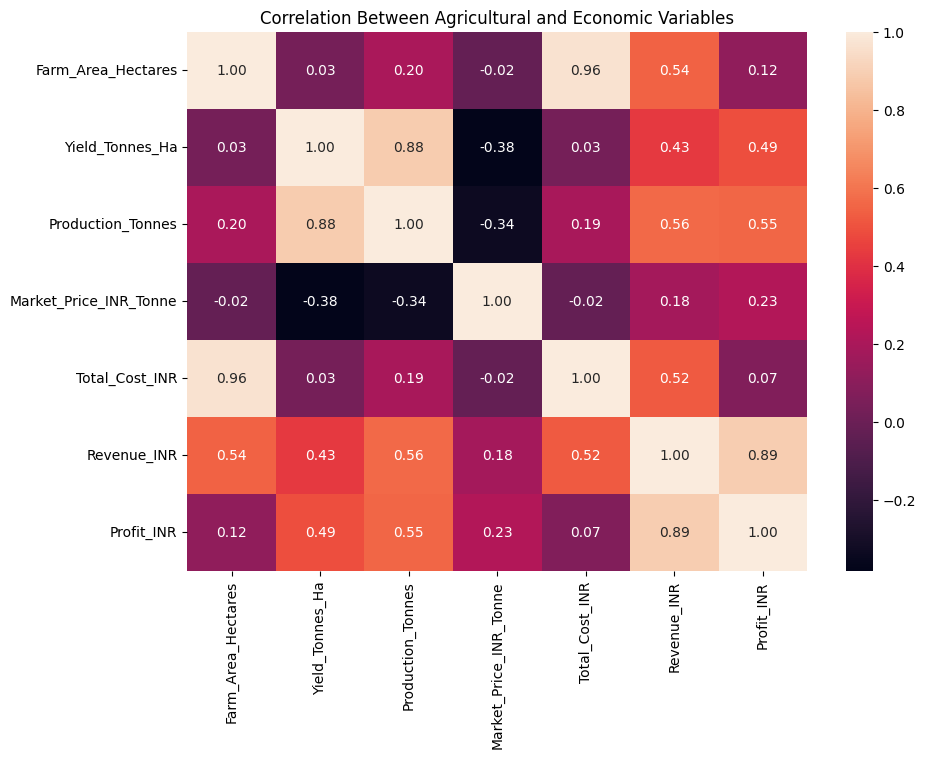

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    economic.corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Agricultural and Economic Variables')
plt.show()

# Question 7
Which season has the highest disease/pest risk?

In [ ]:
risk_season = df.groupby(
    'Season'
)['Disease_Pest_Risk_pct'].mean().sort_values(
    ascending=False
)

risk_season

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


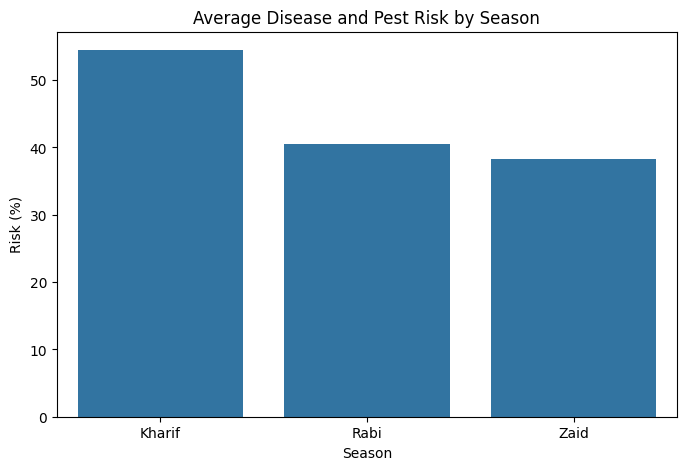

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=risk_season.index,
    y=risk_season.values
)

plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')
plt.show()

# Disease Risk vs Yield

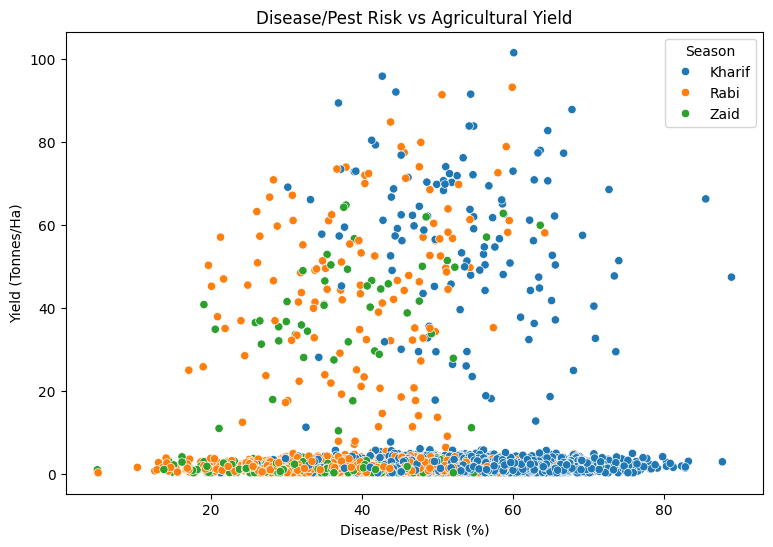

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Disease/Pest Risk vs Agricultural Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

# Question 8
Does irrigation method affect yield?

In [ ]:
irrigation_yield = df.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

irrigation_yield

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


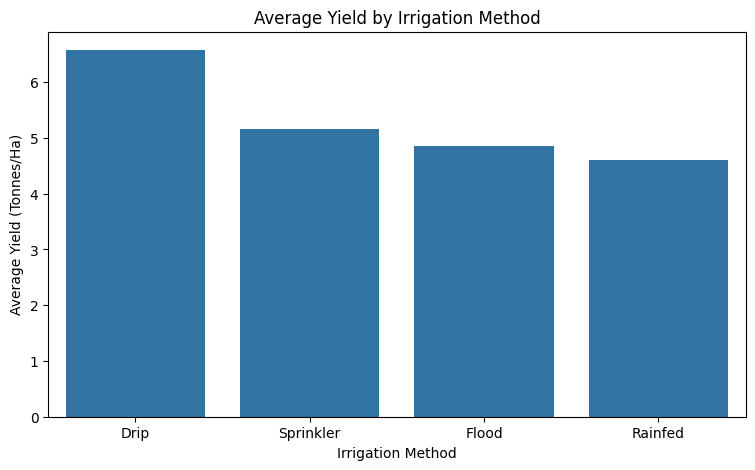

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

# Irrigation + Season

In [ ]:
irrigation_season = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
)

irrigation_season.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.11,5.85
Flood,4.98,5.06,3.98
Rainfed,5.70,3.93,3.06
Sprinkler,4.66,5.31,6.14


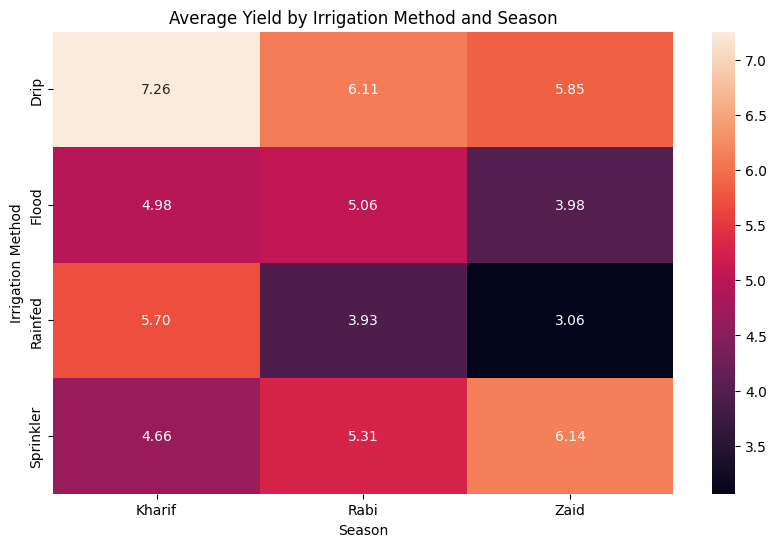

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    irrigation_season,
    annot=True,
    fmt='.2f'
)

plt.title('Average Yield by Irrigation Method and Season')
plt.xlabel('Season')
plt.ylabel('Irrigation Method')
plt.show()

# Statistical Test: Does Yield Differ Across Seasons?

In [ ]:
kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

anova_result = stats.f_oneway(
    kharif,
    rabi,
    zaid
)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)


F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


## Interpretation

In [ ]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print("There is a statistically significant difference in yield across seasons.")
else:
    print("There is no statistically significant difference in yield across seasons.")

There is no statistically significant difference in yield across seasons.


# Season-wise Performance Dashboard Table

In [ ]:
final_season_summary = df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Total_Production=('Production_Tonnes', 'sum'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

final_season_summary

,Farms,Avg_Yield,Total_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,
Kharif,1779,5.63,82387.61,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.04,67498.88,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.64,23098.35,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


# Automatically Find Best/Worst Seasons

In [ ]:
metrics = [
    'Yield_Tonnes_Ha',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3'
]

for metric in metrics:
    result = df.groupby('Season')[metric].mean()

    print("\n", metric)
    print("Best:", result.idxmax(), "=", round(result.max(), 2))
    print("Lowest:", result.idxmin(), "=", round(result.min(), 2))


 Yield_Tonnes_Ha
Best: Kharif = 5.63
Lowest: Zaid = 4.64

 Revenue_INR
Best: Kharif = 710719.06
Lowest: Zaid = 519171.9

 Profit_INR
Best: Kharif = 178914.65
Lowest: Zaid = -24804.82

 Water_Efficiency_t_per_1000m3
Best: Kharif = 5.89
Lowest: Zaid = 4.41


# Find Important Outliers

In [ ]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Yield_Tonnes_Ha'] < lower) |
    (df['Yield_Tonnes_Ha'] > upper)
]

print("Number of yield outliers:", len(outliers))

Number of yield outliers: 302


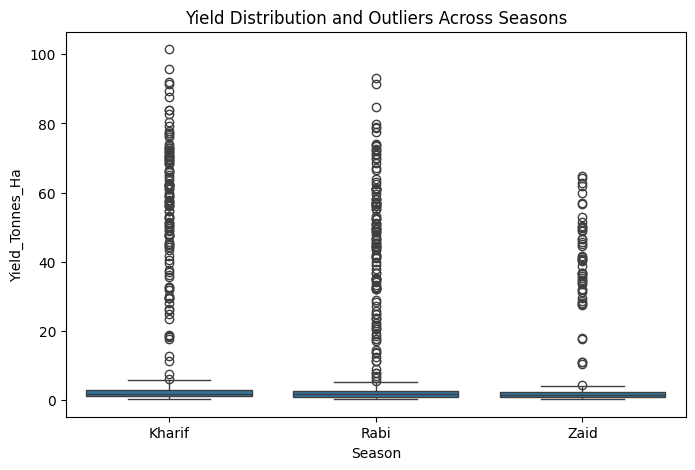

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution and Outliers Across Seasons')
plt.show()

#Important Final Analysis

In [ ]:
season_analysis = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Water_Used_m3': 'mean',
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'sum',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_analysis

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Water_Used_m3,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,
Kharif,849.20,28.45,71.81,31.15,187.08,6102.20,5.63,82387.61,710719.06,178914.65,5.89,54.47
Rabi,437.62,23.49,57.89,24.07,185.41,5846.99,5.04,67498.88,601526.05,87689.47,5.19,40.48
Zaid,304.65,31.04,52.01,19.28,184.64,6419.89,4.64,23098.35,519171.90,-24804.82,4.41,38.22


## Conclusion

This project analyzed agricultural performance across Kharif, Rabi and Zaid
seasons using agricultural, environmental, resource and economic variables.

The analysis compared seasonal differences in yield, production, revenue,
cost, profit, water usage, water efficiency and disease/pest risk.

The results show that agricultural performance varies across seasons.
Environmental conditions and resource usage also show differences between
seasons. Crop and regional comparisons further reveal that seasonal
performance is not uniform across all agricultural categories.

Correlation and statistical analysis were used to investigate relationships
between agricultural performance and environmental/resource variables.

Overall, the analysis provides data-driven insights that can support better
seasonal agricultural planning and resource management.

## Recommendations

1. Seasonal planning should consider the differences in environmental
   conditions observed across Kharif, Rabi and Zaid.

2. Water resources should be managed according to seasonal water usage
   and water-efficiency patterns.

3. Crops showing stronger performance in particular seasons can be
   considered when planning seasonal cultivation.

4. Regions with relatively lower agricultural or economic performance
   should be investigated further.

5. Disease and pest risk should be considered during seasonal crop planning.

6. Fertilizer, irrigation and other agricultural resources should be
   optimized based on their observed relationship with yield.

7. Future analysis can use additional years of data to validate whether
   the observed seasonal patterns remain consistent.